---
title: "PGC v1.3 / v1.4 shielded noise covariance"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-08"
file-modified: "2026-06-11"
abstract: "This adds shielded noise covariance to the versioned PGC input files used by the Clorinn v2 pipeline."
---

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor='black', dpi=300, colors='kelly')
from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Configuration and input files

The input files are taken from v1.1 and v1.2. 
[Click here to view the v1.1 and v1.2 data processing notebook](./2026-04-30-data-preprocessing-v1-1.ipynb).

The output files are versioned using `outsuffix = "v1_3" / "v1_4"` and written to `pgc_v1.3/` and `pgc_v1.4/`.

In [23]:
datadir = "/gpfs/commons/groups/knowles_lab/data/PsychGen/input"
inputdir    = Path(datadir) / "pgc_v1.1"
inputsuffix = "v1_1"
outdir      = Path(datadir) / "pgc_v1.3"
outsuffix   = "v1_3"

# Input files
zscore_file    = Path(inputdir) / f"zscore_{inputsuffix}.csv"
noise_cov_file = Path(inputdir) / f"sampling_covariance_{inputsuffix}.csv"
category_file  = Path(inputdir) / f"trait_to_group_{inputsuffix}.json"

# Output files
def ensure_parent(path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)


shielded_noise_cov_outfile = Path(outdir) / f"shielded_noise_covariance_{outsuffix}.csv"
ensure_parent(shielded_noise_cov_outfile)

# Read files
def load_zscore(zscore_path):
    df = pd.read_csv(Path(zscore_path), header=0, index_col=0, dtype={0: str})
    df.index = df.index.map(str)
    df.columns = df.columns.map(str)
    return df

Z_df = load_zscore(zscore_file)
A_df = pd.read_csv(noise_cov_file, header = 0, index_col=0)
with open(category_file, "r") as f:
    trait_to_group = json.load(f)

## Load genetic correlation from LDSC results

In [24]:
def normalize_trait_name(name):
    rename_map = {
        "Saxena": "Daytime_sleepiness",
    }
    if not isinstance(name, str):
        return name
    name = name.replace("-", "_")
    name = rename_map.get(name, name)
    return str(name)
    

def get_matrix_df_from_json(fpath, check_sanity=True):
    with open(Path(fpath), "r") as f:
        d = json.load(f)
    rows = []
    traits = []
    for a_vs_b, val in d.items():
        trait_a, trait_b = ([normalize_trait_name(x) for x in a_vs_b.split("_vs_")])
        traits.append(trait_a)
        traits.append(trait_b)
        rows.append({
            "trait_a": trait_a,
            "trait_b": trait_b,
            "rg": val,
        })
    traits = sorted(list(set(traits)))
    df = pd.DataFrame(rows)

    n = len(traits)
    R = pd.DataFrame(np.nan, index=traits, columns=traits, dtype=float)
    R.values[R.index.get_indexer(df["trait_a"]),
             R.columns.get_indexer(df["trait_b"])] = df["rg"].to_numpy()
    R.values[R.index.get_indexer(df["trait_b"]),
             R.columns.get_indexer(df["trait_a"])] = df["rg"].to_numpy()

    if check_sanity:
        # Max and min values
        print(f"max={R.max().max():.3g}, min={R.min().min():.3g}")
        # Symmetry sanity (in case the input accidentally contains BOTH directions)
        asym = np.nanmax(np.abs(R.values - R.values.T))
        print(f"max |R - R.T| = {asym:.3g}")   # expect 0.0 if each pair listed once
        
        # Coverage: how many off-diagonal pairs are actually populated?
        off = ~np.eye(len(traits), dtype=bool)
        print(f"populated off-diagonal fraction: {np.isfinite(R.values[off]).mean():.3f}")
        
    return R

R_df = get_matrix_df_from_json(Path(datadir) / "ldsc_results/rg.txt")
np.fill_diagonal(R_df.values, 1.0)

max=3.87, min=-0.893
max |R - R.T| = 0
populated off-diagonal fraction: 0.949


## Shield the sampling covariance

We protected the leading genetic correlation axes of $R_g$, 
choosing the smallest number of axes explaining 80% 
of the positive eigenvalue mass.
We remove these axes from the aggressive covariance correction.

Define the genetic-axis projector $P = U_k U_k^{\top}$, and $Q=I-P$.
Use only the part of noise covariance $S$ in the complement of the genetic axes,

$$
S_{\bot} = QSQ
$$

But $S_{\bot}$ is singular in the full space, so do not directly invert it. Use a shielded precision matrix:

$$
W_{\mathrm{shield}} = U_{\bot} (U^{\top}_{\bot}SU_{\bot} + \delta I)^{-1} U^{\top}_{\bot} + \alpha P
$$

$$
S_{\mathrm{shield}} = U_{\bot} (U^{\top}_{\bot}SU_{\bot} + \delta I) U^{\top}_{\bot} + \frac{1}{\alpha} P
$$

- Directions orthogonal to $R_g$ axes get LDSC-intercept correction.
- Directions aligned with $R_g$ axes are protected.
- $\alpha P$ keeps those directions in the loss with mild isotropic weighting.

A good, heuristic default for $\alpha$ is 

$$ 
\alpha = \frac{1}{p-k}\mathrm{tr}\left[(U^{\top}_{\bot}SU_{\bot} + \delta I)^{-1} \right]
$$

In [25]:
def shield_sampling_covariance(
    S_df, Rg_df, 
    eval_thres=0.8, ridge=1e-4, alpha=None,
    max_k=None, return_info=False,
):
    """
    S_df  : sampling covariance matrix
    Rg_df : genetic correlation matrix
    """

    S = S_df.to_numpy(dtype=float)
    Rg = Rg_df.to_numpy(dtype=float)

    S = 0.5 * (S + S.T)
    Rg = 0.5 * (Rg + Rg.T)

    p = S.shape[0]

    # Eigenvectors of Rg
    evals, evecs = np.linalg.eigh(Rg)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    # Use positive eigenvalue mass only
    evals_pos = np.maximum(evals, 0.0)
    total = evals_pos.sum()
    if total <= 0:
        raise ValueError("Rg has no positive eigenvalue mass.")

    cumvar = np.cumsum(evals_pos) / total
    k = np.searchsorted(cumvar, eval_thres) + 1

    if max_k is not None:
        k = min(k, max_k)

    U_g = evecs[:, :k]

    # Make sure U_g is numerically orthonormal
    U_g, _ = np.linalg.qr(U_g)

    # Complete orthonormal basis
    U_full, _ = np.linalg.qr(U_g, mode="complete")
    U_g = U_full[:, :k]
    U_perp = U_full[:, k:]

    # Covariance in the non-genetic subspace
    S_perp = U_perp.T @ S @ U_perp
    S_perp = 0.5 * (S_perp + S_perp.T)

    vals, vecs = np.linalg.eigh(S_perp)

    # Ridge should be relative to the scale of S
    scale = np.mean(np.diag(S))
    vals = np.maximum(vals, ridge * scale)

    S_perp_psd = vecs @ np.diag(vals) @ vecs.T

    # Precision weight on protected genetic axes.
    # alpha = 1 means isotropic z-score-scale weighting.
    if alpha is None:
        alpha = 1.0 / scale

    P = U_g @ U_g.T

    S_shield = (
        U_perp @ S_perp_psd @ U_perp.T
        + (1.0 / alpha) * P
    )

    S_shield = 0.5 * (S_shield + S_shield.T)

    S_shield_df = pd.DataFrame(
        S_shield,
        index=S_df.index,
        columns=S_df.columns,
    )

    if return_info:
        info = {
            "k": k,
            "cumvar": cumvar[k - 1],
            "alpha": alpha,
            "min_eval_S_perp_before_clip": float(np.min(np.linalg.eigvalsh(S_perp))),
            "min_eval_S_shield": float(np.min(np.linalg.eigvalsh(S_shield))),
            "max_eval_S_shield": float(np.max(np.linalg.eigvalsh(S_shield))),
        }
        return S_shield_df, info

    return S_shield_df

trait_names = list(A_df.index)
shielded_noise_cov, info = shield_sampling_covariance(
    A_df,
    R_df.loc[trait_names, trait_names],
    eval_thres=0.8,
    ridge=1e-4,
    alpha=None,
    max_k=20,
    return_info=True,
)

print(info)

{'k': 14, 'cumvar': 0.8123773647539491, 'alpha': 0.9833548284613144, 'min_eval_S_perp_before_clip': 0.018940662692588418, 'min_eval_S_shield': 0.01894066269258829, 'max_eval_S_shield': 1.693487745013379}


## How different is the shielded noise covariance?

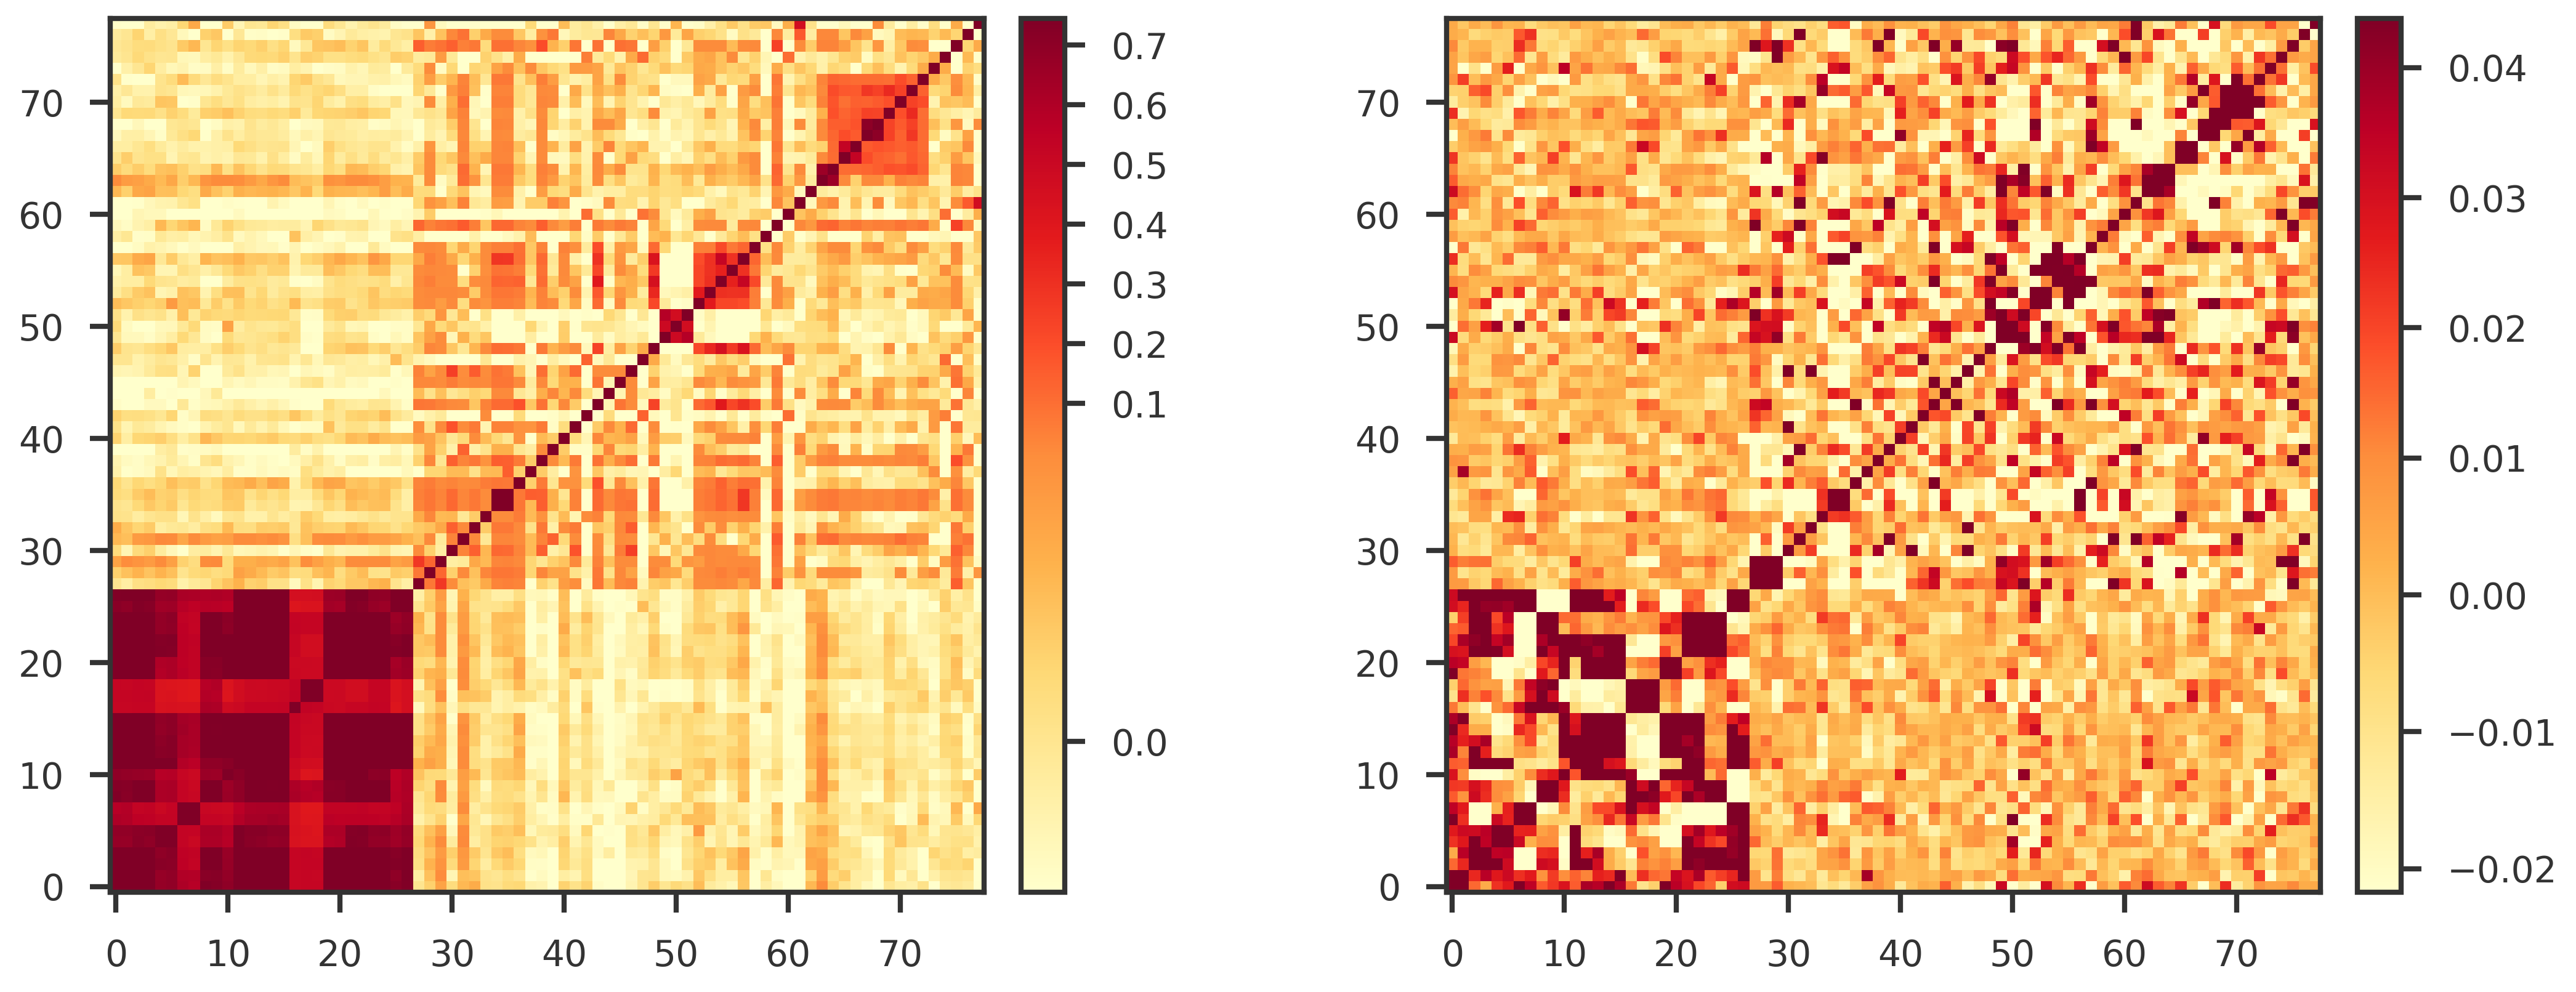

In [26]:
def make_heatmap_figure(A, B):
    
    def get_mpl_norm(X):
        X = np.asarray(X)
        offdiag = ~np.eye(X.shape[0], X.shape[1], dtype=bool)
        ok = np.isfinite(X) & offdiag
        vmin = np.quantile(X[ok], 0.1)
        vmax = np.quantile(X[ok], 0.95)
        # vmax = np.max(X[ok])
        vcenter = np.quantile(X[ok], 0.75)
        return mpl_colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        
    
    A = A.to_numpy()
    B = B.to_numpy()
    
    fig = plt.figure(figsize = (16,8))
    gs  = fig.add_gridspec(nrows=1, ncols=2, wspace=0.4, hspace=0)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()

    im1 = ax1.imshow(A, cmap=cmap1, norm=get_mpl_norm(A), origin='lower')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction=0.1)

    im2 = ax2.imshow(B, cmap=cmap1, norm=get_mpl_norm(B), origin='lower')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im2, cax=cax, fraction=0.1)

    plt.show()
    
make_heatmap_figure(A_df, shielded_noise_cov)

## Validate sampling covariance

The sampling covariance must be numerically well behaved for the correlated-noise Clorinn objective.

We check for symmetry and positive definiteness.

A symmetric positive-definite covariance is required for stable likelihood evaluation, inversion, and missingness-pattern-specific covariance operations downstream.

In [21]:
tol = 1e-8
A = shielded_noise_cov.to_numpy()
is_symmetric = np.allclose(A, A.T, atol=tol, rtol=0)
if is_symmetric:
    print("This matrix is symmetric.")
else:
    print("This matrix is not symmetric.")
    max_asymmetry = np.abs(A - A.T).max()
    print("max_asymmetry:", max_asymmetry)

eigvals = np.linalg.eigvalsh((A + A.T) / 2)
is_pd = np.all(eigvals > 0)

if is_pd:
    print ("This matrix is PD.")
else:
    print ("This matrix is not PD.")
    print (f"Minimum eigenvalue: {eigvals.min():g}")
    print ("Zero / Negative eigenvalues:")
    print(eigvals[eigvals <= 0])


This matrix is symmetric.
This matrix is PD.


## Write release files

The only new release files are `shielded_noise_covariance_v1_3.csv` 
and `shielded_noise_covariance_v1_4.csv`.

Other input files are copied from v1.1 and v1.2 respectively.

In [22]:
shielded_noise_cov.to_csv(shielded_noise_cov_outfile)